                  Choose a book                   
╔══════════════════════════════════════════════════╗
               Pride And Prejudice                
    The Complete Works Of William Shakespeare     
                     Dracula                      
         Alices Adventures In Wonderland          
          Adventures Of Sherlock Holmes           
                       Exit                       
╚══════════════════════════════════════════════════╝



==>> The Complete Works Of William Shakespeare



            Type what chooise you want            
╔══════════════════════════════════════════════════╗
                 Basic Statistics                 
                  Word Analysis                   
                Sentence Analysis                 
                Character Analysis                
                  Export Result                   
                       Back                       
╚══════════════════════════════════════════════════╝



==>> Character Analysis



Character Analysis for The Complete Works Of William Shakespeare.txt
╔══════════════════════════════════════════════════╗
Top 5 most common letters:
e          487743
t          356289
o          334272
a          312188
i          272142
s          269069
n          262449
h          257182
r          253821
l          181675

Character type:
Lowercase  3628644
Uppercase  443670
Digits     1478
Spaces     832295
Punctuation 91384
Rest       381196
╚══════════════════════════════════════════════════╝



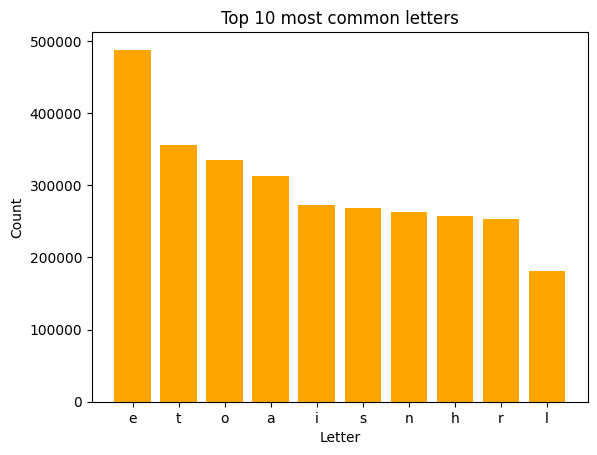

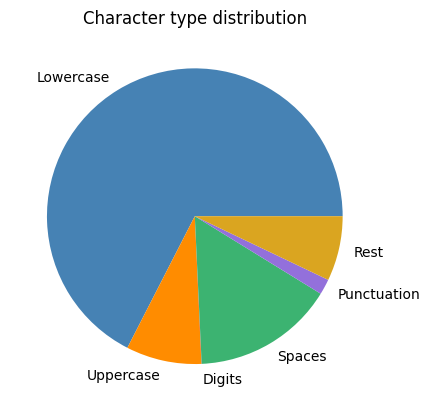

            Type what chooise you want            
╔══════════════════════════════════════════════════╗
                 Basic Statistics                 
                  Word Analysis                   
                Sentence Analysis                 
                Character Analysis                
                  Export Result                   
                       Back                       
╚══════════════════════════════════════════════════╝



==>> export result



Exporting result...

            Type what chooise you want            
╔══════════════════════════════════════════════════╗
                 Basic Statistics                 
                  Word Analysis                   
                Sentence Analysis                 
                Character Analysis                
                  Export Result                   
                       Back                       
╚══════════════════════════════════════════════════╝



KeyboardInterrupt: Interrupted by user

In [2]:
import matplotlib.pyplot as plt

#---> The Complete Works Of William Shakespeare är bäst för bredast statistik. Den vissar även att all visalizering fungerar bäst men den tar dock längre tid att ladda.

#---> Word Analysis

def Word_analysis(Link, Unique_word):
    Word_count = {}
    Word_length = []
    Words_appearing_only_once = set()
    Unique_word_count = 0
    
    Unique_word = Unique_word.lower()
    
    with open(Link, "r", encoding="utf-8") as Book:

        for Line in Book:
            Words = Line.split()

            for Word in Words:
                Word = Word.lower()

                Words_appearing_only_once.add(Word)

                Word_length.append(len(Word))

                if Word == Unique_word:
                    Unique_word_count += 1

                if Word in Word_count:
                    Word_count[Word] += 1
                    
                else:
                    Word_count[Word] = 1

    Word_count = sorted(Word_count.items(), key = lambda x: x[1], reverse = True) #items gör de till en turple, key - x[1] sorterar det i storleks ordning, rev vänder de baklänges
    Word_count = Word_count[:10]

    Words_appearing_only_once = len(Words_appearing_only_once)

    Word_length.sort()
    

    return Word_count, Word_length, Words_appearing_only_once, Unique_word_count

def Visualisations_word(Link):

    Result = Word_analysis(Link, '')
        
    x, y = zip(*Result[0])

    plt.bar(x, y, color='turquoise') #bar: fast data som i en dic
    plt.title('Top 10 most common worlds')
    plt.xlabel('Word')
    plt.ylabel('Count')
    plt.show()

    
    plt.hist(Result[1], bins=range(1, 25), color='red') #hist: rådata, bins: delar upp datan i ''fack'' från 1 till max längd
    plt.title("Word Length Distribution")
    plt.xlabel("Word Length (characters)")
    plt.ylabel("Frequency")
    plt.show()

#---> Character Analysis

def Character_analysis(Link):
    Letter_count = {}
    Character_type = {'Lowercase': 0, 'Uppercase': 0, 'Digits': 0, 'Spaces': 0, 'Punctuation': 0, 'Rest': 0,}

    with open(Link, "r", encoding="utf-8") as Book:

        for Line in Book:

            for Letter in Line:

                if 'a' <= Letter <= 'z':
                    Character_type['Lowercase'] += 1
                    
                elif 'A' <= Letter <= 'Z':
                    Character_type['Uppercase'] += 1

                elif '0' <= Letter <= '9':
                    Character_type['Digits'] += 1

                elif Letter == ' ':
                    Character_type['Spaces'] += 1

                elif Letter == '.':
                    Character_type['Punctuation'] += 1

                else:
                    Character_type['Rest'] += 1

                Letter = Letter.lower()
                
                if Letter.isalpha():
                    if Letter in Letter_count:
                        Letter_count[Letter] += 1
                
                    else:
                        Letter_count[Letter] = 1

                    
    Letter_count = sorted(Letter_count.items(), key = lambda x: x[1], reverse = True)
    Letter_count = Letter_count[:10]

    return Letter_count, Character_type

def Visualisations_character(Link):

    Result = Character_analysis(Link)
        
    x, y = zip(*Result[0])

    plt.bar(x, y, color='orange')
    plt.title('Top 10 most common letters')
    plt.xlabel('Letter')
    plt.ylabel('Count')
    plt.show()

    Pie_colors = ['steelblue', 'darkorange', 'crimson', 'mediumseagreen', 'mediumpurple', 'goldenrod']          

    plt.pie(Result[1].values(), labels = Result[1].keys(), colors = Pie_colors) #Keys blir namnen och values blir hur stor varje del är
    plt.title('Character type distribution')
    plt.show()

#---> Basic Statistics

def Basic_statistics(Link):

    Link = open(Link, 'r')
    Counters = {'Words' : 0,
                'Lines' : 0,
                'Characters' : 0,
                'All characters' : 0,
                'Sentences' : 0,
                'Average words per line' : 0,
                'Average word length' : 0,
                'Average words per sentence' : 0}
    
    for Line in Link:
        Counters['All characters'] += len(Line)
        for Letter in Line:
            if Letter != ' ':
                Counters['Characters'] += 1
            if Letter in '.!?':
                Counters['Sentences'] += 1        
        Line = Line.split()
        Counters['Lines'] += 1
        
        for Word in Line:
            Counters['Words'] += 1

    Link.close()
    
    Counters['Average words per line'] =  round(Counters['Words'] / Counters['Lines'], 2)
    Counters['Average word length'] = round(Counters['Characters'] / Counters['Words'], 2)
    Counters['Average words per sentence'] = round(Counters['Words'] / Counters['Sentences'], 2)

    return Counters

def Visualisations_statistics(Link):

    Result_characters = Character_analysis(Link)
    Result_statistics = Basic_statistics(Link)
    Result_word = Word_analysis(Link, '')

    Punctuations = Result_characters[1]['Punctuation']
    Spaces = Result_characters[1]['Spaces']
    Letters = (Result_characters[1]['Uppercase'] + Result_characters[1]['Lowercase'])
    

    plt.bar(('Lines', 'Sentences', 'UW'), 
            (Result_statistics['Lines'], 
             Result_statistics['Sentences'], 
             Result_word[2]), 
             color=('steelblue', 'darkorange', 'crimson'))
    plt.title('Text Composition')
    plt.ylabel('Count')
    plt.show()


    Pie_colors = ['crimson', 'darkorange', 'steelblue']          

    plt.pie((Punctuations, Spaces, Letters),
            labels = ('Punctuations', 'Spaces', 'Letters'), 
            colors = Pie_colors, 
            autopct="%.1f%%")
    plt.title('Character type distribution')
    plt.show()

#---> Sentence Analysis

def Sentence_analysis(File):
    Top_length = {}
    Sentence_length = []
    Temp_sentence = ''
    Longest = ''
    Shortest =  'Jakob är snäll och vacker, hans leende lyser och hans hjärta värmer alla.'

    with open(File, 'r', encoding='utf-8') as Book:

        for Line in Book: 
            Line = Line.strip()

            for Letter in Line:
                Temp_sentence += Letter


                if Letter in '.!?' and len(Temp_sentence) >= 1:
                    Temp_sentence = Temp_sentence.strip().split()
                    Sentence_length.append(len(Temp_sentence))

                    if len(Temp_sentence) in Top_length:
                        Top_length[len(Temp_sentence)] += 1
                    else:
                        Top_length[len(Temp_sentence)] = 1

                    if len(Temp_sentence) > len(Longest):
                        Longest = Temp_sentence

                    if len(Temp_sentence) < len(Shortest) and len(Temp_sentence) >= 1:
                        Shortest = Temp_sentence

                    Temp_sentence = ''

    Top_length = sorted(Top_length.items(), key = lambda x: x[1], reverse = True) #items gör de till en turple, key - x[1] sorterar det i storleks ordning, rev vänder de baklänges
    Top_length = Top_length[:5]

    return Sentence_length, Longest, Shortest, Top_length

def Sentence_visualisation(Link):

    Visualisations_statistics = Sentence_analysis(Link)

    plt.hist(Visualisations_statistics[0], 
             bins=range(1, 100), 
             color='#1f77b4',
             edgecolor='#333333') #hist: rådata, bins: delar upp datan i ''fack'' från 1 till max längd
    plt.title("Word Length Distribution")
    plt.xlabel("Word Length (characters)")
    plt.ylabel("Frequency")
    plt.show()


    sorted_data = sorted(Visualisations_statistics[3], key=lambda x: x[1], reverse=True)
    x, y = zip(*sorted_data)

    x = [str(i) for i in x]

    bars = plt.bar(x, y, color='turquoise', edgecolor='#333333')
    plt.title('Top 5 Most Common Sentence Lengths')
    plt.xlabel('Sentence Length (words)')
    plt.ylabel('Number of Sentences')

    for bar in bars:
        val = int(bar.get_height())
    plt.show()

#---> Export

def Export(Link):
    Result_basic = Basic_statistics(Link)
    Result_word = Word_analysis(Link, '')
    Result_character = Character_analysis(Link)
    Result_sentence = Sentence_analysis(Link)


    Average = sum(Result_word[1]) / len(Result_word[1])
    Average = round(Average, 1)

    with open('Result.' + Link, "w", encoding="utf-8") as File:

        File.write('TEXT ANALYSIS RESULTS\n')
        File.write('-' * 25 + '\n')
        File.write(f'File analysed: {Link}\n\n')

        #--->
        
        File.write('Basic Statistics:\n')
        File.write('-' * 25 + '\n')
        for Word, Count in Result_basic.items():
            File.write(f'{Word: <15} {Count}\n')
        File.write('\n')

        #--->
        
        File.write('Word Analysis:\n')
        File.write('-' * 25 + '\n')
        File.write(f'Shortest word: {min(Result_word[1])}\n')
        File.write(f'Longest word: {max(Result_word[1])}\n')
        File.write(f'Average length: {Average}\n')
        File.write(f'Words appearing only once: {Result_word[2]}\n\n')

        File.write('Top 10 most common words:\n')
        for Word, Count in Result_word[0]:
            File.write(f'{Word: <15} {Count}\n')
        File.write('\n')

        #--->
        
        File.write('Sentence Analysis:\n')
        File.write('-' * 25 + '\n')
        File.write(f'Longest sentence is {max(Result_sentence[0])} words:\n"')
        File.write(' '.join(Result_sentence[1][:30]) + '..."\n')

        File.write(f'Shortest sentence is {min(Result_sentence[0])} word(s):\n"')
        File.write(' '.join(Result_sentence[2]) + '"\n\n')

        File.write('Sentence length distribution (top 5):\n')
        for Length, Count in Result_sentence[3]:
            File.write(f'{Length} words: {Count: >10} sentences\n')
        File.write('\n')

        #--->
        
        File.write('Character Analysis:\n')
        File.write('-' * 25 + '\n')
        File.write('Top 5 most common letters:\n')
        for Letter, Count in Result_character[0]:
            File.write(f'{Letter: <10} {Count}\n')

        File.write('Character type:\n')
        for Character, Count in Result_character[1].items():
            File.write(f'{Character: <15} {Count}\n')

#---> Meny / Main

def Meny():
    Top_Line = '\u2554' + '\u2550' * 50 + '\u2557'
    Bottom_Line = '\u255A' + '\u2550' * 50 + '\u255D'
    Choice = ''

    Books = {'Pride And Prejudice': 'Pride And Prejudice.txt',
             'The Complete Works Of William Shakespeare': 'The Complete Works Of William Shakespeare.txt', #Vill du ha bredast statistic så välj denna, så ser du att allt verkligen funkar. Men tar längre tid att ladda
             'Dracula': 'Dracula.txt',
             'Alices Adventures In Wonderland': 'Alices Adventures In Wonderland.txt',
             'Adventures Of Sherlock Holmes': 'Adventures Of Sherlock Holmes.txt',
    }
                
    while Choice != 'Exit':
        
        print(f'{'Choose a book':^50}')
        print(Top_Line)

        for Name in Books:
            print(f'{Name:^50}')
            
        print(f'{'Exit':^50}')
        print(Bottom_Line)
        print()
        
        Choice = input('==>>')
        Choice = Choice.strip().title()


        if Choice in Books:
            print()
            
            Link = Books[Choice]
            
            while Choice != 'Back':
                
                print(f'{'Type what chooise you want':^50}')
                print(Top_Line)
                
                print(f'{'Basic Statistics':^50}')
                print(f'{'Word Analysis':^50}')
                print(f'{'Sentence Analysis':^50}')
                print(f'{'Character Analysis':^50}')
                print(f'{'Export Result':^50}')

      
                print(f'{'Back':^50}')
                print(Bottom_Line)
                print()
                
                Choice = input('==>>')
                Choice = Choice.strip().capitalize().replace(' ','')

                if Choice == 'Basicstatistics':

                    Result = Basic_statistics(Link)
                    
                    print()
                    print(f'Basic Statistics for {Link}')
                    print(Top_Line)
  
                    for Word, Count in Result.items():
                        print(f'{Word: <10} {Count}')
                    
                    print(Bottom_Line)
                    print()

                    Visualisations_statistics(Link)
                    
                elif Choice == 'Wordanalysis':
                    
                    print()
                    print(f'Type the word you want to search for in the text:')
                    Word = input('==>>')
                    print()
                    
                    Result = Word_analysis(Link, Word)

                    Avrage = sum(Result[1]) / len(Result[1])
                    Avrage = round(Avrage, 1)

                    print(f'Word Analysis for {Link}')
                    print(Top_Line)

                    print(f'Shortest word: {min(Result[1])}')
                    print(f'Longest word: {max(Result[1])}')
                    print(f'Avrage lenght: {Avrage}')
                    print(f'Words appering only once: {Result[2]}')
                    print(f'Your word: {Word} appered {Result[3]} times in the text')
                    print()

                    print(f'Top 10 most common worlds:')
                    for Word, Count in Result[0]:
                        print(f'{Word: <10} {Count}')
                        
                    print(Bottom_Line)
                    print()

                    Visualisations_word(Link)

                elif Choice == 'Sentenceanalysis':

                    Result = Sentence_analysis(Link)
                
                    print()
                    print(f'Sentence Analysis for {Link}')
                    print(Top_Line)
                    
                    print(f'Longest sentance is {max(Result[0])} words:')
                    print('" ', end='')
                    for Word in Result[1][:30]:
                        print(Word, end=' ')
                    print('.."')
                    print()
                    
                    print(f'Shortest sentance is {min(Result[0])} word(s):')
                    print('" ', end='')
                    for Word in Result[2]:
                        print(Word, end=' ')
                    print('"')
                    print()
                    
                    print(f'Sentence length distribution (top 5):', sep='')
                    for Word, Count in Result[3]:
                        print(f'{Word} words: {Count: >10} sentences')

                    print(Bottom_Line)
                    print()

                    Sentence_visualisation(Link)
                     
                elif Choice == 'Characteranalysis':
                    print()

                    Result = Character_analysis(Link)

                    print(f'Character Analysis for {Link}')
                    print(Top_Line)

                    print(f'Top 5 most common letters:')
                    for Letter, Count in Result[0]:
                        print(f'{Letter: <10} {Count}')

                    print()

                    print(f'Character type:')
                    for Character, Count in Result[1].items():
                        print(f'{Character: <10} {Count}')
                        
                    print(Bottom_Line)
                    print()

                    Visualisations_character(Link)
                    
                elif Choice == 'Exportresult':
                    print()
                    print('Exporting result...')

                    Export(Link)
                    print()

                elif Choice == 'Back':
                    print()
                    
                else:
                    print('Didnt find your choice')
                    
                    print()
                
        elif Choice == 'Exit':
            print('Exit program') 
            print()
            
        else:
            print('Error, Try again')
            print()

Meny()